In [1]:
import pandas as pd

In [2]:
store = pd.read_csv("../data/raw/store.csv")
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")


C:\Users\PHUC\AppData\Local\Temp\ipykernel_988\3412143650.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


- train k missing/duplicate

In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


- Store missing nhiều, không duplicate

### Merge data

In [5]:
# 2. GỘP DỮ LIỆU (MERGE)

# Gộp Train và Store dựa trên cột 'Store'
train_merged = pd.merge(train, store, on='Store', how='left')

# Gộp Test và Store dựa trên cột 'Store'
test_merged = pd.merge(test, store, on='Store', how='left')

In [6]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [7]:
# 1. Chuyển Date về datetime 
train_merged['Date'] = pd.to_datetime(train_merged['Date'])
test_merged['Date'] = pd.to_datetime(test_merged['Date'])
# 2. Chuẩn hóa StateHoliday về string để tránh lẫn lộn giữa số 0 và chữ '0'
# Lưu ý: .astype(str) sẽ biến NaN thành chuỗi 'nan', nên ta dùng cách map để giữ nguyên None/NaN
train_merged['StateHoliday'] = train_merged['StateHoliday'].map(lambda x: str(x) if pd.notnull(x) else x)

# 5. Kiểm tra lại
print(train_merged.info())
print("\nSố lượng giá trị thiếu (vẫn giữ nguyên):")
print(train_merged.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [8]:
train_merged.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

- Handle missing 

In [9]:
#kiểm tra những cột missing ở cột CompetitionDistance là của Store nào 
a = train_merged[train_merged['CompetitionDistance'].isnull()][['Store', 'Date']]
a['Store'].unique()

array([291, 622, 879])

In [10]:
import numpy as np
# 1. Vá lỗ hổng bằng số 0
train_merged['CompetitionDistance'] = train_merged['CompetitionDistance'].fillna(0)
test_merged['CompetitionDistance'] = test_merged['CompetitionDistance'].fillna(0)

# 2. Tạo biến Log ngay sau khi vá (Dùng log1p để log(0+1) không bị lỗi)
train_merged['CompetitionDistance_log'] = np.log1p(train_merged['CompetitionDistance'])
test_merged['CompetitionDistance_log'] = np.log1p(test_merged['CompetitionDistance'])

# Vá lỗ hổng bằng số 0 
cols_fill_zero = ['Promo2SinceWeek','CompetitionDistance_log','Promo2SinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
train_merged[cols_fill_zero] = train_merged[cols_fill_zero].fillna(0)
test_merged[cols_fill_zero] = test_merged[cols_fill_zero].fillna(0)

train_merged['PromoInterval'] = train_merged['PromoInterval'].fillna('None')
test_merged['PromoInterval'] = test_merged['PromoInterval'].fillna('None')

print(" Đã vá xong 3 'hố đen' 291, 622, 879. Toàn bộ lịch sử đã được giữ lại!")

 Đã vá xong 3 'hố đen' 291, 622, 879. Toàn bộ lịch sử đã được giữ lại!


In [11]:
train_merged.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompetitionDistance_log      0
dtype: int64

In [12]:
test_merged.isnull().sum()

Id                            0
Store                         0
DayOfWeek                     0
Date                          0
Open                         11
Promo                         0
StateHoliday                  0
SchoolHoliday                 0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                 0
CompetitionDistance_log       0
dtype: int64

In [13]:
train_merged['CompetitionOpenSinceMonth'] = train_merged['CompetitionOpenSinceMonth'].astype('int8')
train_merged['CompetitionOpenSinceYear'] = train_merged['CompetitionOpenSinceYear'].astype('int16')
train_merged['Promo2SinceWeek'] = train_merged['Promo2SinceWeek'].astype('int8')
train_merged['Promo2SinceYear'] = train_merged['Promo2SinceYear'].astype('int16')

In [14]:
# 1. Ép kiểu các cột phân loại 
cat_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
for col in cat_cols:
    train_merged[col] = train_merged[col].astype('category')
    test_merged[col] = test_merged[col].astype('category')
# Kiểm tra lại thành quả
print(train_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 no

In [15]:
train_merged.duplicated().sum()

np.int64(0)

## Test_merged

In [16]:
test_merged.isnull().sum()  

Id                            0
Store                         0
DayOfWeek                     0
Date                          0
Open                         11
Promo                         0
StateHoliday                  0
SchoolHoliday                 0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                 0
CompetitionDistance_log       0
dtype: int64

- Có mỗi Store 622 bị thiếu ngày open 

In [17]:
 # 1. Điền Open cho Store 622 (11 ngày thiếu ta đã chứng minh là nên điền 1)
test_merged['Open'] = test_merged['Open'].fillna(1)
#ép kiểu cột 'Open' về int8
test_merged['Open'] = test_merged['Open'].astype('int8')

In [18]:
# 1. Ép kiểu số nguyên nhỏ (int8, int16)
test_merged['CompetitionOpenSinceMonth'] = test_merged['CompetitionOpenSinceMonth'].astype('int8')
test_merged['Promo2SinceWeek'] = test_merged['Promo2SinceWeek'].astype('int8')

# 2. Ép kiểu số nguyên vừa (int16, int32)
test_merged['Id'] = test_merged['Id'].astype('int32')
test_merged['CompetitionOpenSinceYear'] = test_merged['CompetitionOpenSinceYear'].astype('int16')
test_merged['Promo2SinceYear'] = test_merged['Promo2SinceYear'].astype('int16')

# 4. Ép kiểu Phân loại (Category)
# Lưu ý: StateHoliday cần ép về str trước để đồng nhất '0' và 0
test_merged['StateHoliday'] = test_merged['StateHoliday'].astype(str).astype('category')
test_merged['StoreType'] = test_merged['StoreType'].astype('category')
test_merged['Assortment'] = test_merged['Assortment'].astype('category')
test_merged['PromoInterval'] = test_merged['PromoInterval'].astype('category')

# KIỂM TRA LẠI
print(test_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int32         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int64         
 3   Date                       41088 non-null  datetime64[ns]
 4   Open                       41088 non-null  int8          
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  category      
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  category      
 9   Assortment                 41088 non-null  category      
 10  CompetitionDistance        41088 non-null  float64       
 11  CompetitionOpenSinceMonth  41088 non-null  int8          
 12  Comp

In [19]:
test_merged.duplicated().sum()

np.int64(0)

### Xong missing và duplicate 

In [20]:
# Lọc tập Train: Chỉ giữ lại những ngày cửa hàng mở và có doanh số > 0
print(train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] > 0)].count())
train_merged = train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] > 0)]   

Store                        844338
DayOfWeek                    844338
Date                         844338
Sales                        844338
Customers                    844338
Open                         844338
Promo                        844338
StateHoliday                 844338
SchoolHoliday                844338
StoreType                    844338
Assortment                   844338
CompetitionDistance          844338
CompetitionOpenSinceMonth    844338
CompetitionOpenSinceYear     844338
Promo2                       844338
Promo2SinceWeek              844338
Promo2SinceYear              844338
PromoInterval                844338
CompetitionDistance_log      844338
dtype: int64


# Outliers


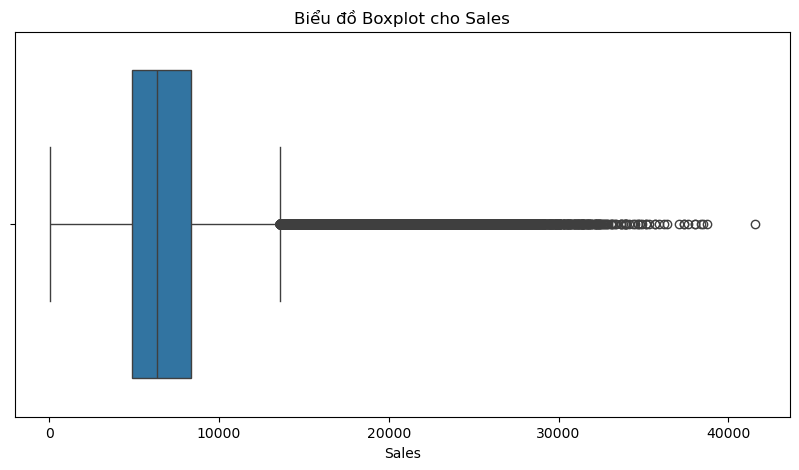

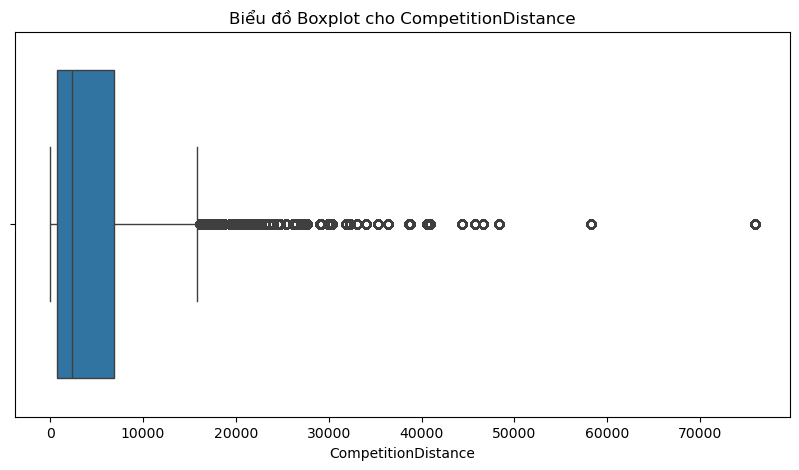

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers(df, column):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Biểu đồ Boxplot cho {column}')
    plt.show()

# Soi Outlier của Sales và CompetitionDistance
plot_outliers(train_merged, 'Sales')
plot_outliers(train_merged, 'CompetitionDistance')


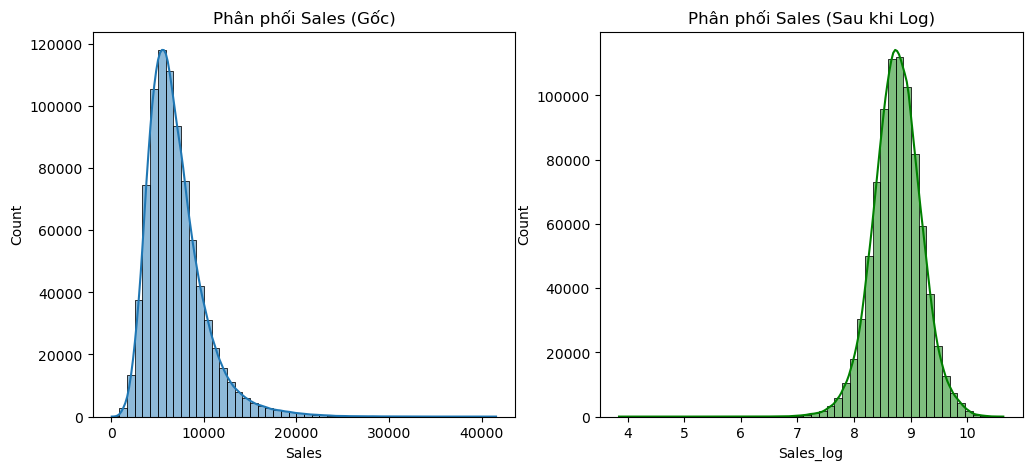

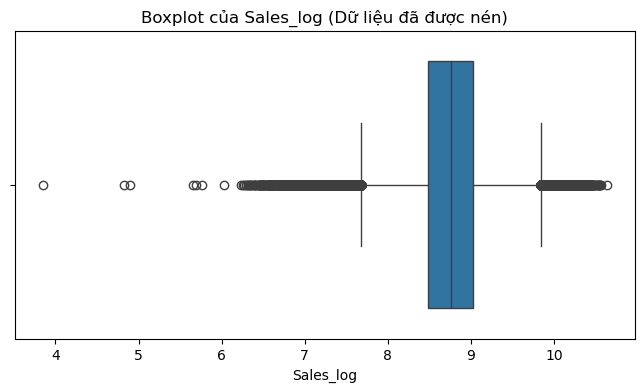

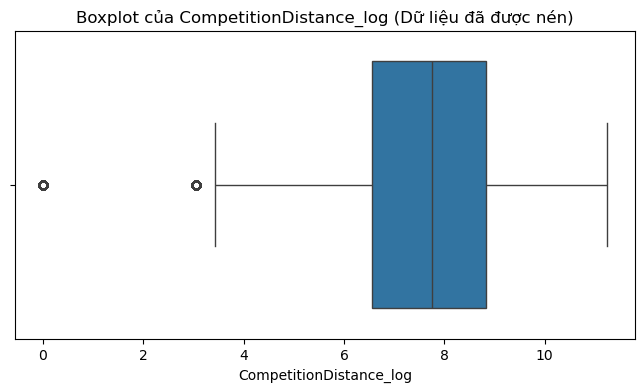

In [22]:
import numpy as np

# 2. Áp dụng Log Transformation (log1p = log(1+x) để tránh lỗi nếu có giá trị 0)
train_merged['Sales_log'] = np.log1p(train_merged['Sales'])
# 3. Kiểm tra lại sự thay đổi bằng biểu đồ
plt.figure(figsize=(12, 5))

# Biểu đồ trước khi Log
plt.subplot(1, 2, 1)
sns.histplot(train_merged['Sales'], kde=True, bins=50)
plt.title('Phân phối Sales (Gốc)')

# plt.subplot(1, 2, 1)
# sns.histplot(train_merged['CompetitionDistance'], kde=True, bins=50)
# plt.title('Phân phối CompetitionDistance (Gốc)')

# Biểu đồ sau khi Log
plt.subplot(1, 2, 2)
sns.histplot(train_merged['Sales_log'], kde=True, bins=50, color='green')
plt.title('Phân phối Sales (Sau khi Log)')

plt.show()

# 4. Xem lại Boxplot để thấy Outlier đã được "thu phục" như thế nào
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_merged['Sales_log'])
plt.title('Boxplot của Sales_log (Dữ liệu đã được nén)')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_merged['CompetitionDistance_log'])
plt.title('Boxplot của CompetitionDistance_log (Dữ liệu đã được nén)')
plt.show()

C:\Users\PHUC\AppData\Local\Temp\ipykernel_988\1889206246.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


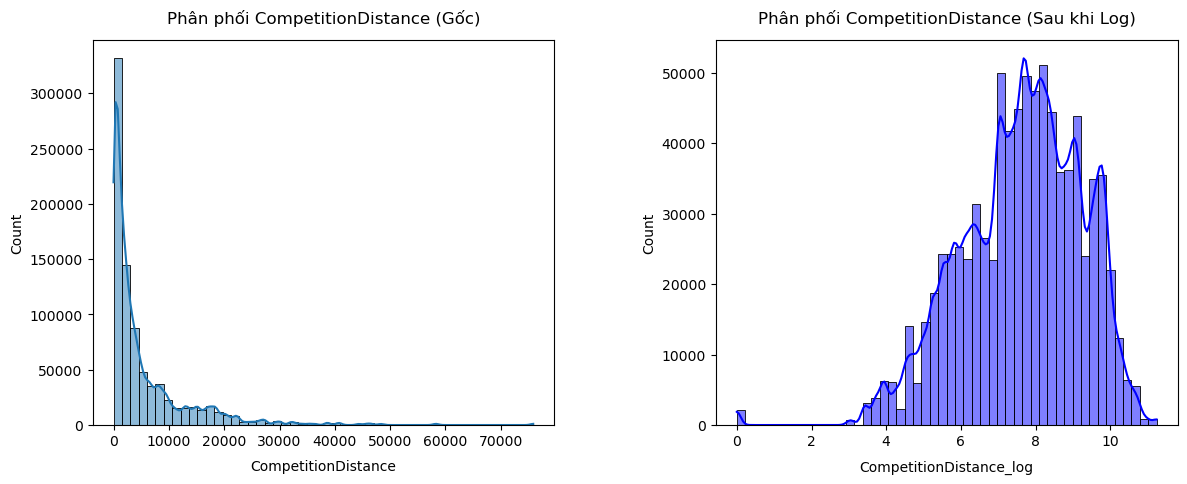

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'wspace': 0.35})

sns.histplot(train_merged['CompetitionDistance'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Phân phối CompetitionDistance (Gốc)', pad=12)

sns.histplot(train_merged['CompetitionDistance_log'], kde=True, bins=50, color='blue', ax=axes[1])
axes[1].set_title('Phân phối CompetitionDistance (Sau khi Log)', pad=12)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), labelpad=8)

plt.tight_layout()
plt.show()

In [24]:
import numpy as np

# Giả sử tên cột của bạn là 'CompetitionDistance_log'
column_name = 'CompetitionDistance_log'

# Bước 1: Tính toán các phân vị và khoảng cách IQR
Q1 = train_merged[column_name].quantile(0.25)
Q3 = train_merged[column_name].quantile(0.75)
IQR = Q3 - Q1

# Bước 2: Xác định ngưỡng (Bounds)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Bước 3: Lọc ra các dòng bị coi là Outlier
outliers_df = train_merged[(train_merged[column_name] < lower_bound) | (train_merged[column_name] > upper_bound)]

# Bước 4: Hiển thị kết quả
print(f"--- Thống kê Outlier cho {column_name} ---")
print(f"Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
print(f"Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
print(f"Số lượng dòng bị coi là outlier: {len(outliers_df)}")
print("-" * 30)

# Xem các giá trị log duy nhất bị coi là outlier
print("Các giá trị Log bị coi là Outlier:")
print(outliers_df[column_name].unique())

# Nếu bạn muốn xem giá trị mét (m) gốc tương ứng:
print("\nGiá trị khoảng cách (mét) gốc tương ứng:")
print(np.expm1(outliers_df[column_name].unique()).round(0))

--- Thống kê Outlier cho CompetitionDistance_log ---
Ngưỡng dưới (Lower Bound): 3.13
Ngưỡng trên (Upper Bound): 12.26
Số lượng dòng bị coi là outlier: 2965
------------------------------
Các giá trị Log bị coi là Outlier:
[0.         3.04452244]

Giá trị khoảng cách (mét) gốc tương ứng:
[ 0. 20.]


- Thay vì cắt bỏ hay sửa dữ liệu, ta dùng hàm Logarit. Đây là cách "nhốt" Outlier vào một cái lồng hẹp hơn.Công thức:
    $$Sales_{log} = \ln(Sales + 1)$$
Tại sao: Nó biến phân phối bị lệch (nhiều outlier) về gần với phân phối chuẩn (Gaussian). Mô hình sẽ không bị "choáng" bởi con số 40,000 nữa vì sau khi Log, nó chỉ còn loanh quanh con số 10.

- Cột Sales: Dùng để chúng ta soi, kiểm tra và tính toán thực tế (human-readable).

- Cột Sales_log: Dùng làm Target (biến mục tiêu) để đưa vào các thuật toán Machine Learning (AI-readable).

### 1. Tại sao không xử lý Outlier ở cột Sales (Target)?
- Trong hầu hết các bài toán Regression, người ta hay sợ outlier, nhưng với Sales của Rossmann thì lại khác:Nó là "Tín hiệu", không phải "Nhiễu": Những ngày doanh số vọt lên cực cao (outlier) thường rơi vào các dịp lễ hội, Giáng sinh, hoặc ngày có Promo cực mạnh. 
- Đó chính là những ngày quan trọng nhất cần dự báo đúng. Nếu xóa nó đi, Model sẽ không bao giờ học được cách bắt đỉnh (Peak).Log Transformation: Chúng ta đã dùng 
                        $$Sales\_log = \log(1 + Sales)$$
Hàm Log có đặc tính "nén" các giá trị cực lớn lại.
 - Ví dụ: $\log(100)$ và $\log(1000)$ khoảng cách sẽ hẹp hơn nhiều so với $100$ và $1000$ đơn vị gốc.Việc này đã tự động làm cho phân phối dữ liệu "hiền" hơn mà không cần xóa bất kỳ dòng nào.
 -  số RMSPE: Cuộc thi này chấm điểm bằng $RMSPE$. Việc dự báo lệch ở những ngày doanh số cao sẽ kéo sai số đi rất xa. Nếu "gọt" bớt outlier ở Train, Model sẽ dự báo thấp hơn thực tế ở Test, dẫn đến điểm $RMSPE$ "toang" ngay lập tức.

### 2. Tại sao không xử lý Outlier ở cột CompetitionDistance (Feature)?
- Với cột này, lý do nằm ở bản chất của thuật toán XGBoost/LightGBM mà ta đang dùng:

Thuật toán cây (Tree-based) cực lì với Outlier: Các model cây không quan tâm giá trị tuyệt đối là bao nhiêu, nó chỉ quan tâm đến Điểm chia (Split Point).

Dù đối thủ ở cách 50,000m hay 500,000m (outlier), nếu máy quyết định chia ở mức 1,000m, thì tất cả những thằng > 1,000m đều bị xếp vào cùng một nhóm "Đối thủ ở xa - Không ảnh hưởng". Số 500,000m không làm lệch cái cây như cách nó làm lệch đường hồi quy tuyến tính (Linear Regression).

Ý nghĩa kinh doanh: Một khoảng cách cực xa thực chất mang một thông tin: "Cửa hàng này không có đối thủ". Nếu xóa những dòng có distance quá lớn, ta đang trực tiếp xóa đi những cửa hàng có điều kiện kinh doanh thuận lợi nhất.

Log Transformation (Lại là nó): ta đã dùng CompetitionDistance_log. Việc này đã kéo các giá trị hàng chục nghìn mét về một thang đo nhỏ hơn (0 đến 10), giúp máy tính toán ổn định hơn mà vẫn giữ được thứ tự xa-gần.

## Feature Engineering

In [25]:
#Bỏ cột Customers và Open
train_merged = train_merged.drop(columns=['Customers', 'Open'])

In [26]:
train_merged['StateHoliday'].unique()

['0', 'a', 'b', 'c']
Categories (4, object): ['0', 'a', 'b', 'c']

In [27]:
def extract_row_logic(df):
    df = df.copy()

    # 1. Date Components
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['DayOfWeek'] = df['Date'].dt.weekday + 1  # Thứ 2=1, ..., Chủ nhật=7
    
    # --- FEATURE HOLIDAY DUY NHẤT (0 hoặc 1) ---
    # 2. NHÓM HOLIDAY (Đơn giản hóa để tránh Overfitting)
    # Map StateHoliday: '0'->0, 'a'->1, 'b'->2, 'c'->3
    holiday_map = {'0': 0, 'a': 1, 'b': 2, 'c': 3}
    df['StateHoliday'] = df['StateHoliday'].astype(str).map(holiday_map).fillna(0).astype(int)
    # SchoolHoliday: Giữ nguyên 0/1 (Vì nó có nhiều dữ liệu, máy học rất tốt)
    
    # --- LỚP 1: TÍNH TOÁN TUYẾN TÍNH (THƯỚC KẺ) ---
    # Promo2: Quy về Tuần
    sales_total_weeks = df['Year'] * 52 + df['WeekOfYear']
    promo_start_weeks = df['Promo2SinceYear'] * 52 + df['Promo2SinceWeek']
    df['Promo2Open_Month'] = (sales_total_weeks - promo_start_weeks) / 4.0
    
    # Competition: Quy về Tháng
    sales_total_months = df['Year'] * 12 + df['Month']
    comp_start_months = df['CompetitionOpenSinceYear'] * 12 + df['CompetitionOpenSinceMonth']
    df['CompetitionOpen_Month'] = sales_total_months - comp_start_months

    # --- LỚP 2: TRẢM (GHI ĐÈ CÁC CA LỖI LOGIC & MISSING) ---
    # Nếu Store không tham gia Promo2, Open_Month phải là 0
    df.loc[df['Promo2'] == 0, 'Promo2Open_Month'] = 0
    # Nếu SinceYear bị missing (lỡ fill 0), Open_Month cũng phải là 0
    df.loc[df['Promo2SinceYear'] == 0, 'Promo2Open_Month'] = 0
    
    # Tương tự cho Competition: Nếu không có ngày bắt đầu (fill 0), coi như không có
    df.loc[df['CompetitionOpenSinceYear'] == 0, 'CompetitionOpen_Month'] = 0

    # --- LỚP 3: GỌT (CHẶN TRẦN & CHẶN SÀN) ---
    # Clip(lower=0): Xử lý các ca "Xuyên không" (Ngày bán < Ngày bắt đầu)
    # Clip(upper=24): Xử lý các ca "Hóa thạch" (Ngày mở từ 1900)
    df['Promo2Open_Month'] = df['Promo2Open_Month'].clip(lower=0, upper=24)
    df['CompetitionOpen_Month'] = df['CompetitionOpen_Month'].clip(lower=0, upper=24)
    
    
    # --- 2. KIỂM TRA CHU KỲ KHUYẾN MÃI (Is_Promo2_Month) ---
    # Map tháng hiện tại sang tên viết tắt (Khớp với format trong PromoInterval)
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
    df['month_name'] = df['Month'].map(month_map)
    # Khởi tạo cột bằng 0
    df['Is_Promo2_Month'] = 0
    # Chỉ những Store có Promo2=1 và PromoInterval khác 'None' mới cần check
    mask = (df['Promo2'] == 1) & (df['PromoInterval'] != 'None') & (df['PromoInterval'] != '')
    # Check xem tháng hiện tại (month_name) có nằm trong danh sách khuyến mãi không
    # Ví dụ: 'Jan' có trong 'Jan,Apr,Jul,Oct' không?
    df.loc[mask, 'Is_Promo2_Month'] = df[mask].apply(
        lambda x: 1 if x['month_name'] in x['PromoInterval'] else 0, axis=1
    )
    # Xóa cột tạm cho sạch bộ nhớ
    df = df.drop(columns=['month_name'])
    
    
    # 2. Tuổi đời đối thủ: Tính ra số tháng để máy bắt được Trend
    # Lưu ý: Cần xử lý kỹ các giá trị 0 hoặc NaN từ bước Merged
    df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].replace(0, np.nan)
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].replace(0, np.nan)
    print("Min - Max năm mở cửa đối thủ trước khi xử lý:", df['CompetitionOpenSinceYear'].min(), "-", df['CompetitionOpenSinceYear'].max())
    df['CompetitionOpen_Month'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear'].fillna(df['Year'])) + \
                                  (df['Month'] - df['CompetitionOpenSinceMonth'].fillna(df['Month']))
                                  
    print("Min - Max tuổi đối thủ sau khi xử lý:", df['CompetitionOpen_Month'].min(), "-", df['CompetitionOpen_Month'].max())
    df.loc[df['CompetitionOpen_Month'] < 0, 'CompetitionOpen_Month'] = 0
    
    
    # 5. NHÓM ĐẶC TÍNH STORE (DNA cửa hàng)
    # Map đơn giản theo bảng chữ cái: a,b,c,d -> 0,1,2,3
    store_map = {'a': 0, 'b': 1, 'c': 2, 'd': 3}
    assort_map = {'a': 0, 'b': 1, 'c': 2}
    df['StoreType'] = df['StoreType'].map(store_map).astype(int)
    df['Assortment'] = df['Assortment'].map(assort_map).astype(int)
    return df

# Chạy cho cả 2 tập dữ liệu ban đầu
train_processed = extract_row_logic(train_merged)
test_processed = extract_row_logic(test_merged)

Min - Max năm mở cửa đối thủ trước khi xử lý: 1900.0 - 2015.0
Min - Max tuổi đối thủ sau khi xử lý: -31.0 - 1386.0
Min - Max năm mở cửa đối thủ trước khi xử lý: 1900.0 - 2015.0
Min - Max tuổi đối thủ sau khi xử lý: 0.0 - 1388.0


In [28]:
train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int32         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Promo                      844338 non-null  int64         
 5   StateHoliday               844338 non-null  int64         
 6   SchoolHoliday              844338 non-null  int64         
 7   StoreType                  844338 non-null  int64         
 8   Assortment                 844338 non-null  int64         
 9   CompetitionDistance        844338 non-null  float64       
 10  CompetitionOpenSinceMonth  575738 non-null  float64       
 11  CompetitionOpenSinceYear   575738 non-null  float64     

In [29]:
test_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int32         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int32         
 3   Date                       41088 non-null  datetime64[ns]
 4   Open                       41088 non-null  int8          
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  int64         
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  int64         
 9   Assortment                 41088 non-null  int64         
 10  CompetitionDistance        41088 non-null  float64       
 11  CompetitionOpenSinceMonth  25872 non-null  float64       
 12  Comp

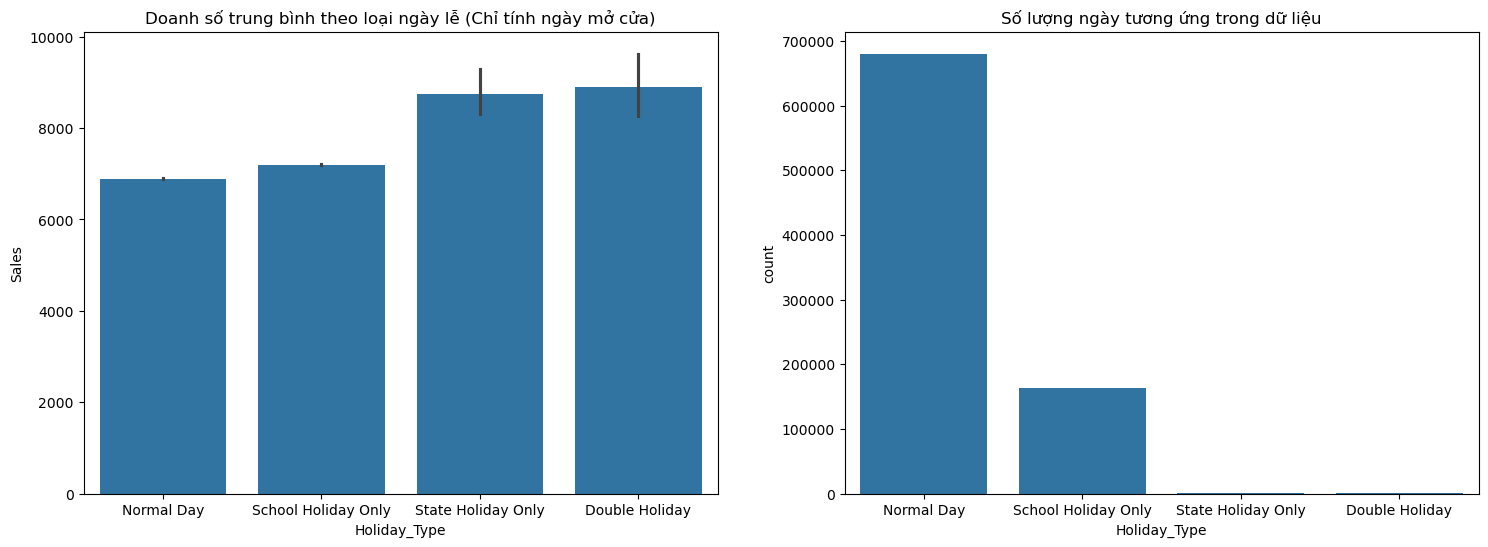

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu: Chỉ xét những ngày cửa hàng MỞ CỬA (Open == 1)
# Vì nếu đóng cửa thì Sales = 0, biểu đồ sẽ bị lệch
holiday_df = train_merged

# 2. Tạo cột phân loại nhanh để vẽ
def classify_holiday(row):
    if row['StateHoliday'] != '0' and row['SchoolHoliday'] == 1:
        return 'Double Holiday'
    elif row['StateHoliday'] != '0':
        return 'State Holiday Only'
    elif row['SchoolHoliday'] == 1:
        return 'School Holiday Only'
    else:
        return 'Normal Day'

holiday_df['Holiday_Type'] = holiday_df.apply(classify_holiday, axis=1)

# 3. Vẽ biểu đồ so sánh Sales trung bình và số lượng ngày lễ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Sales trung bình
sns.barplot(data=holiday_df, x='Holiday_Type', y='Sales', ax=ax1, 
            order=['Normal Day', 'School Holiday Only', 'State Holiday Only', 'Double Holiday'])
ax1.set_title("Doanh số trung bình theo loại ngày lễ (Chỉ tính ngày mở cửa)")

# Biểu đồ 2: Số lượng quan sát (Để xem dữ liệu có bị hiếm quá không)
sns.countplot(data=holiday_df, x='Holiday_Type', ax=ax2,
              order=['Normal Day', 'School Holiday Only', 'State Holiday Only', 'Double Holiday'])
ax2.set_title("Số lượng ngày tương ứng trong dữ liệu")

plt.show()

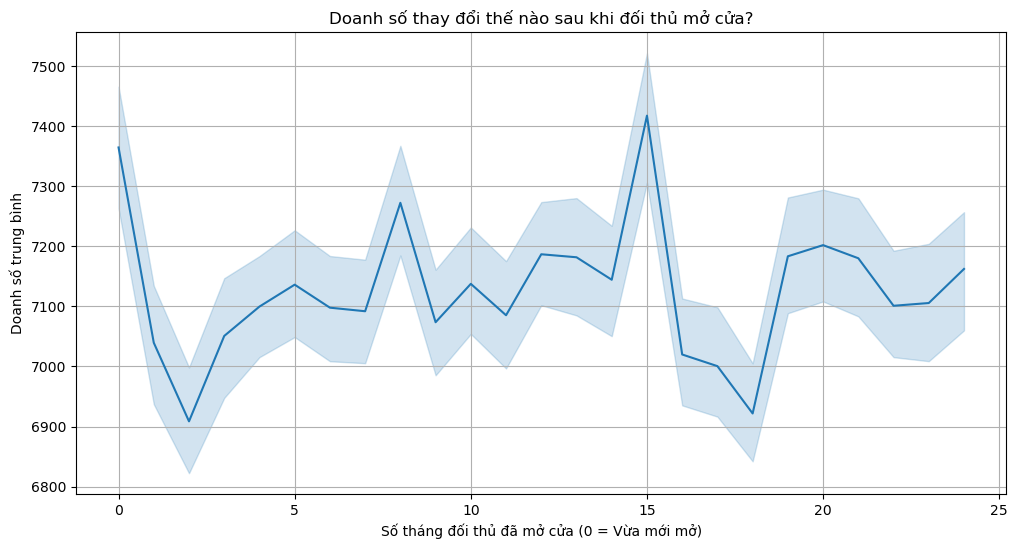

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử ta tính nhanh số tháng đối thủ đã mở (tạm thời)
temp_df = train_processed[['Sales', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'Year', 'Month']].copy()

# Lọc bỏ những dòng không có thông tin đối thủ
temp_df = temp_df[temp_df['CompetitionOpenSinceYear'] > 0]

# Tính số tháng đối thủ đã mở tính đến thời điểm hiện tại
temp_df['Comp_Age'] = 12 * (temp_df['Year'] - temp_df['CompetitionOpenSinceYear']) + \
                       (temp_df['Month'] - temp_df['CompetitionOpenSinceMonth'])

# Chỉ lấy những đối thủ mở trong vòng 2 năm gần đây (để thấy biến động rõ nhất)
# Và lọc bỏ những giá trị âm (đối thủ chưa mở)
plot_df = temp_df[(temp_df['Comp_Age'] >= 0) & (temp_df['Comp_Age'] <= 24)]

# Vẽ biểu đồ xu hướng Doanh số theo "tuổi" đối thủ
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Comp_Age', y='Sales')
plt.title("Doanh số thay đổi thế nào sau khi đối thủ mở cửa?")
plt.xlabel("Số tháng đối thủ đã mở cửa (0 = Vừa mới mở)")
plt.ylabel("Doanh số trung bình")
plt.grid(True)
plt.show()

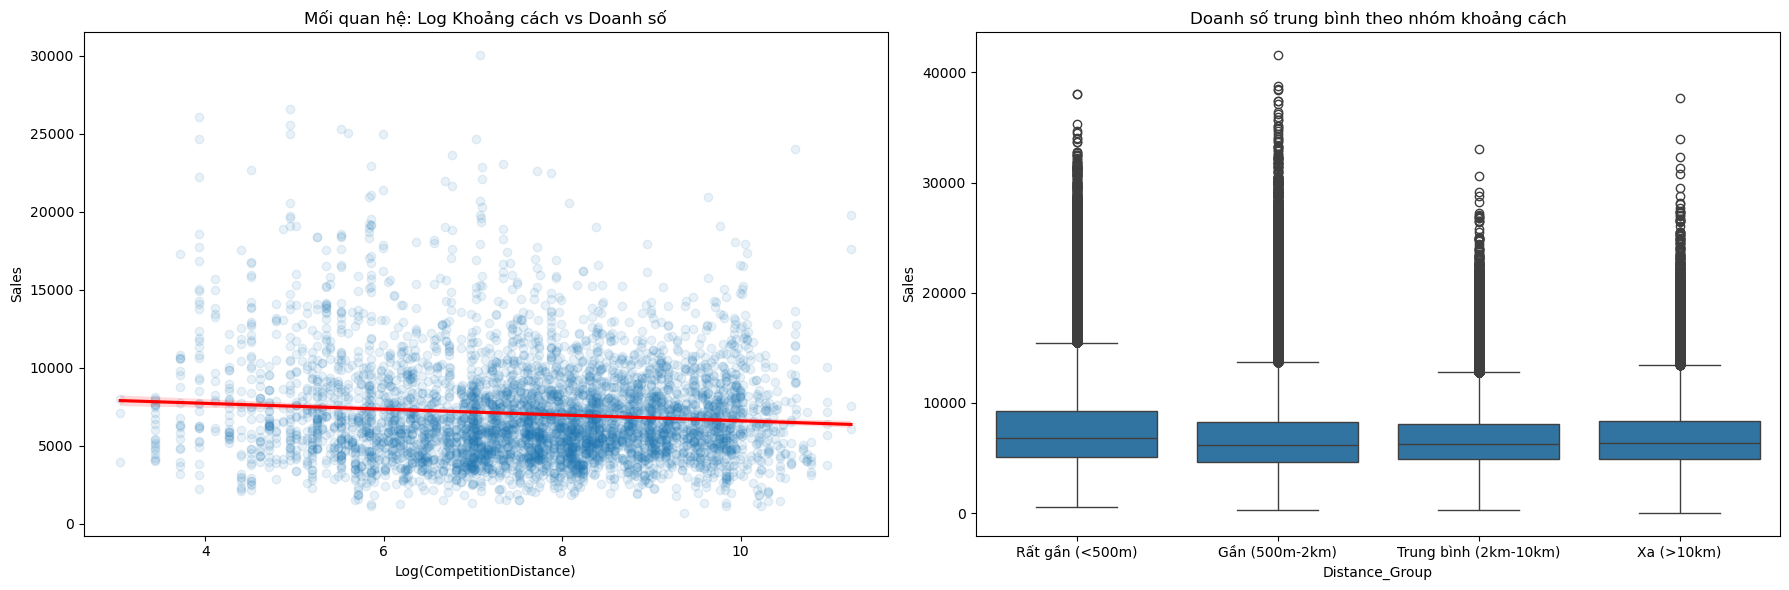

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Chuẩn bị dữ liệu (Lọc những Store có đối thủ)
temp_df = train_merged[train_merged['CompetitionDistance'] > 0].copy()

# 2. Tạo biến Log ngay tại đây để so sánh
temp_df['CompetitionDistance_log'] = np.log1p(temp_df['CompetitionDistance'])

# 3. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Mối quan hệ giữa Log Distance và Sales (Dùng Regplot để thấy xu hướng)
sns.regplot(data=temp_df.sample(5000), x='CompetitionDistance_log', y='Sales', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, ax=ax1)
ax1.set_title("Mối quan hệ: Log Khoảng cách vs Doanh số")
ax1.set_xlabel("Log(CompetitionDistance)")

# Biểu đồ 2: Phân nhóm khoảng cách để thấy sự khác biệt rõ rệt
# Chia khoảng cách thành các nhóm: Rất gần (<500m), Gần (500-2km), Xa (>2km)
temp_df['Distance_Group'] = pd.cut(temp_df['CompetitionDistance'], 
                                   bins=[0, 500, 2000, 10000, 100000], 
                                   labels=['Rất gần (<500m)', 'Gần (500m-2km)', 'Trung bình (2km-10km)', 'Xa (>10km)'])

sns.boxplot(data=temp_df, x='Distance_Group', y='Sales', ax=ax2)
ax2.set_title("Doanh số trung bình theo nhóm khoảng cách")

plt.tight_layout()
plt.show()

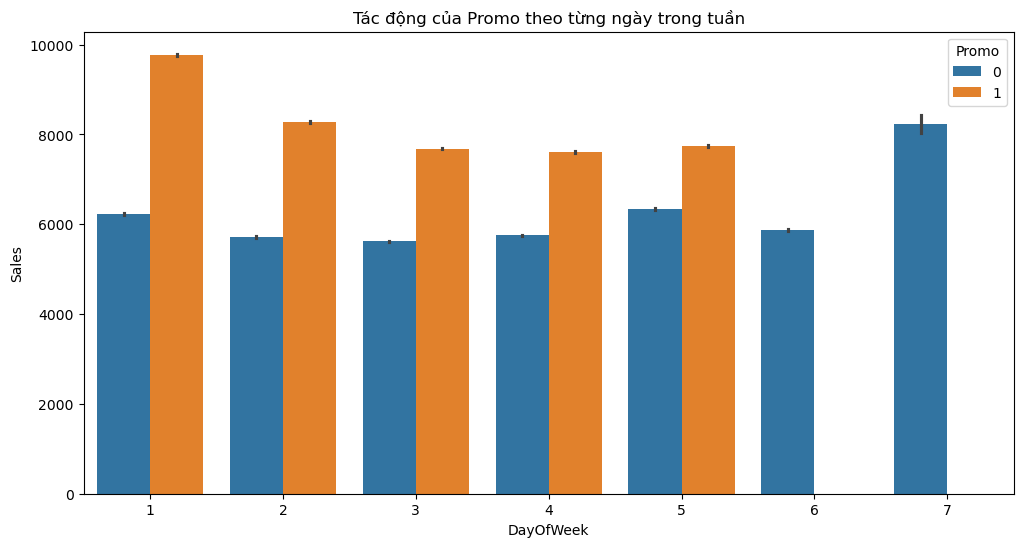

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Vẽ xu hướng Promo theo ngày trong tuần
plt.figure(figsize=(12, 6))
sns.barplot(data=train_merged, x='DayOfWeek', y='Sales', hue='Promo')
plt.title("Tác động của Promo theo từng ngày trong tuần")
plt.show()

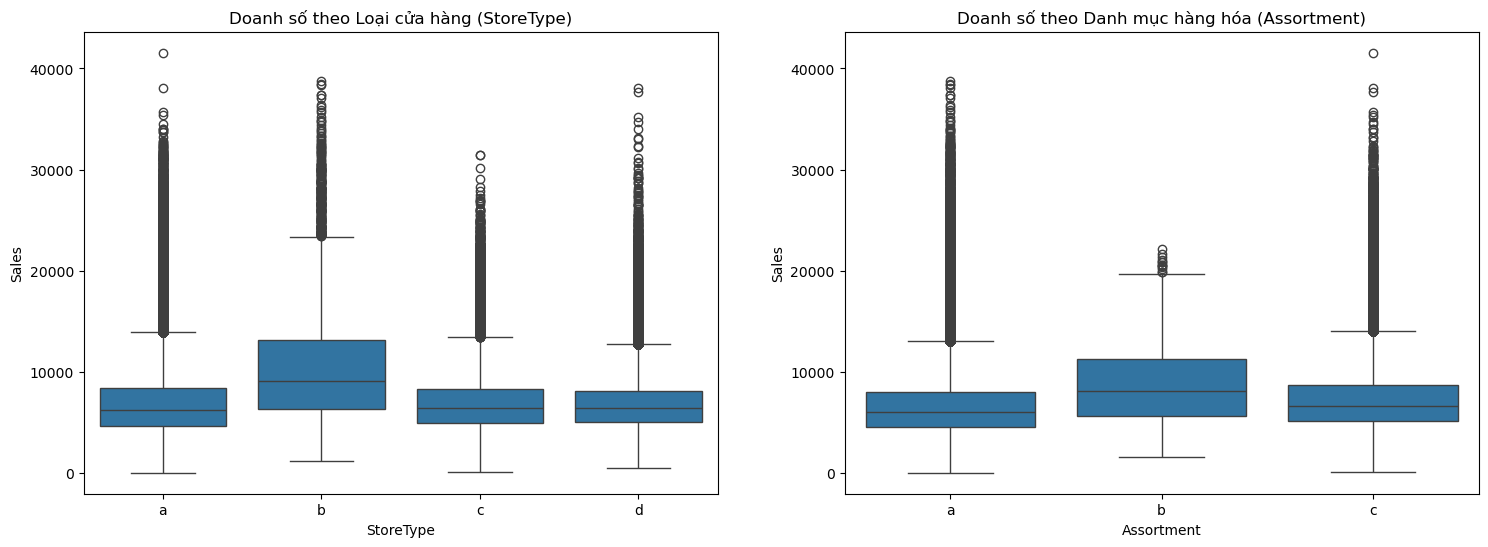

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Soi StoreType
sns.boxplot(data=train_merged, x='StoreType', y='Sales', ax=ax1, order=['a', 'b', 'c', 'd'])
ax1.set_title("Doanh số theo Loại cửa hàng (StoreType)")

# Soi Assortment
sns.boxplot(data=train_merged, x='Assortment', y='Sales', ax=ax2, order=['a', 'b', 'c'])
ax2.set_title("Doanh số theo Danh mục hàng hóa (Assortment)")

plt.show()

In [35]:
#drop các cột không cần thiết
columns_to_drop = [
    'Date', 
    'CompetitionDistance', 
    'CompetitionOpenSinceMonth', 
    'CompetitionOpenSinceYear', 
    'Promo2SinceWeek', 
    'Promo2SinceYear', 
    'PromoInterval'
]
train_final = train_processed.drop(columns=columns_to_drop)
test_final = test_processed.drop(columns=columns_to_drop)

In [36]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    844338 non-null  int64  
 1   DayOfWeek                844338 non-null  int32  
 2   Sales                    844338 non-null  int64  
 3   Promo                    844338 non-null  int64  
 4   StateHoliday             844338 non-null  int64  
 5   SchoolHoliday            844338 non-null  int64  
 6   StoreType                844338 non-null  int64  
 7   Assortment               844338 non-null  int64  
 8   Promo2                   844338 non-null  int64  
 9   CompetitionDistance_log  844338 non-null  float64
 10  Sales_log                844338 non-null  float64
 11  Year                     844338 non-null  int32  
 12  Month                    844338 non-null  int32  
 13  Day                      844338 non-null  int32  
 14  WeekOfYe

In [37]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       41088 non-null  int32  
 1   Store                    41088 non-null  int64  
 2   DayOfWeek                41088 non-null  int32  
 3   Open                     41088 non-null  int8   
 4   Promo                    41088 non-null  int64  
 5   StateHoliday             41088 non-null  int64  
 6   SchoolHoliday            41088 non-null  int64  
 7   StoreType                41088 non-null  int64  
 8   Assortment               41088 non-null  int64  
 9   Promo2                   41088 non-null  int64  
 10  CompetitionDistance_log  41088 non-null  float64
 11  Year                     41088 non-null  int32  
 12  Month                    41088 non-null  int32  
 13  Day                      41088 non-null  int32  
 14  WeekOfYear            

In [38]:
# Kiểm tra kết quả
print(f"Số cột tập Train: {train_final.shape[1]}")
print(f"Số cột tập Test: {test_final.shape[1]}")

Số cột tập Train: 18
Số cột tập Test: 18


# Sửa một chút phần FE

In [39]:
train_final.drop(columns=['Sales'], inplace=True, errors='ignore')
test_final.drop(columns=['Open'], inplace=True, errors='ignore')

In [40]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    844338 non-null  int64  
 1   DayOfWeek                844338 non-null  int32  
 2   Promo                    844338 non-null  int64  
 3   StateHoliday             844338 non-null  int64  
 4   SchoolHoliday            844338 non-null  int64  
 5   StoreType                844338 non-null  int64  
 6   Assortment               844338 non-null  int64  
 7   Promo2                   844338 non-null  int64  
 8   CompetitionDistance_log  844338 non-null  float64
 9   Sales_log                844338 non-null  float64
 10  Year                     844338 non-null  int32  
 11  Month                    844338 non-null  int32  
 12  Day                      844338 non-null  int32  
 13  WeekOfYear               844338 non-null  int64  
 14  Promo2Op

In [41]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       41088 non-null  int32  
 1   Store                    41088 non-null  int64  
 2   DayOfWeek                41088 non-null  int32  
 3   Promo                    41088 non-null  int64  
 4   StateHoliday             41088 non-null  int64  
 5   SchoolHoliday            41088 non-null  int64  
 6   StoreType                41088 non-null  int64  
 7   Assortment               41088 non-null  int64  
 8   Promo2                   41088 non-null  int64  
 9   CompetitionDistance_log  41088 non-null  float64
 10  Year                     41088 non-null  int32  
 11  Month                    41088 non-null  int32  
 12  Day                      41088 non-null  int32  
 13  WeekOfYear               41088 non-null  int64  
 14  Promo2Open_Month      

In [42]:
# Xuất file train_final và test_final đã được xử lý
train_final.to_csv("../data/processed/train_final.csv", index=False)
test_final.to_csv("../data/processed/test_final.csv", index=False)